# Metadata Analysis
analysis of the meta data from Bundesarchiv

ideas:
- cuts and their correlation to length & decision
- distribution over the year (doc counts, etc)

# Imports

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Load & prepare Data

## Load
Duration approx. 4min

In [154]:
BASE_DIR = Path("S:/Zulassungskarten_Data/R_9346-I_Zulassungskarten")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            # data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")

df = pd.DataFrame(metadata)

# df

## Helper Function

In [155]:
# einheitliche alle einstellungen machen, anstatt bei jedem einzeln
def save_plts(fig, name):
    fig.savefig(name, dpi=300)

## Prepare Data

In [156]:
# convert string to datetime
df['Prüfdatum_parsed'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')

# extract year from Datetime and save in extra column
df['Jahr'] = df['Prüfdatum_parsed'].dt.year.astype('Int64')


# convert Prüfnummer to number
df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

# sort by Prüfnummer
df = df.sort_values(by='Prüfnummer')

# df

C:\Users\maris\AppData\Local\Temp\ipykernel_23596\1865301060.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Prüfdatum_parsed'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')


### Correct Errors

In [157]:
df.loc[df["Jahr"].eq(1917), ["_file_name", "Jahr", "Prüfdatum", "Prüfdatum_parsed"]]

,_file_name,Jahr,Prüfdatum,Prüfdatum_parsed
19196,R 9346-I_27293.json,1917,16.1.1917,1917-01-16
19256,R 9346-I_27347.json,1917,27.1.1917,1917-01-27
19274,R 9346-I_27363.json,1917,16.2.1917,1917-02-16


In [158]:
df.loc[df["_file_name"] == "R 9346-I_27347.json", "Jahr"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27363.json", "Jahr"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27293.json", "Jahr"] = 1937

## Dipslay DF

In [159]:
with pd.option_context("display.max_columns", None):
    display(df)

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
0,R 9346-I/1\nDie Wölfin.\n1920 - 1945,nach Kürzung 1480 m,2.0,24.6.1920,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1.json,NaN,NaN,1920-06-24,1920
11095,R 9346-I/2\nDie Spieler\n1920 - 1945,NaN,7.0,25.6.1920,"Asslan-Film Continental, Berlin","Asslan-Film Continental, Berlin",Deutschland,Spielfilm,Stummfilm,2379,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2.json,NaN,NaN,1920-06-25,1920
22200,R 9346-I/3\nSowas kommt von Sowas\n1920 - 1945,NaN,9.0,24.6.1920,"Karfiol-Film, Berlin","Karfiol-Film, Berlin",Deutschland,Spielfilm,Stummfilm,505,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_3.json,NaN,NaN,1920-06-24,1920
29603,R 9346-I/4\nDer Gefangene. (Sklaven des XX. Ja...,LF260322: Durch Blut und Eisen,11.0,9.7.1920,"Kowo Gesellschaft, Berlin","Kowo Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,1833,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_4.json,NaN,NaN,1920-07-09,1920
30707,R 9346-I/5\nDie entfesselte Menschheit\n1920 -...,NaN,20.0,29.6.1920,"Nivo-Film-Comp. GmbH, Berlin","Nivo-Film-Comp. GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,2453,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_5.json,NaN,NaN,1920-06-29,1920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29122,R 9346-I/36536\nDrei ehrliche Banditen.,Originalquelle Zulassungskarte unvollständig O...,NaN,NaN,Deutsche Vereinsfilm AG,Fox-Film Corporation,USA,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36487.json,NaN,NaN,NaT,<NA>
29132,R 9346-I/36536\nDrei ehrliche Banditen.,Originalquelle Zulassungskarte unvollständig O...,NaN,NaN,Deutsche Vereinsfilm AG,Fox-Film Corporation,USA,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36536.json,NaN,NaN,NaT,<NA>
29135,R 9346-I/36539\nDie Macht der Versuchung.\n192...,Originalquelle Zulassungskarte unvollständig (...,NaN,NaN,Projektions-AG Union (PAGU),Projektions-AG Union (PAGU),Deutschland,Spielfilm,Stummfilm,NaN,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36539.json,NaN,NaN,NaT,<NA>
29216,R 9346-I/36611\nAlgol (Der Tragödie der Macht....,"nur 1 Blatt, ohne Prüfnummer",NaN,NaN,Universum-Film Aktiengesellschaft,Universum-Film Aktiengesellschaft,Deutschland,Spielfilm,Stummfilm,2144,NaN,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36611.json,NaN,NaN,NaT,<NA>


# Analyze some weird findings

In [160]:
# df[df['Prüfnummer'] == 33959]

In [161]:
gefilterter_df = df[df['Vorführungsbeschränkung'].notna()]
gefilterter_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
29221,R 9346-I/36624\nSorgenkinder\n1920 - 1945,"nach Kürzung 308 m ""folgender Teil ist verbote...",1696.0,29.3.1921,NaN,Piccolo Grotesk Film-Ges.,Deutschland,Spielfilm,Stummfilm,312,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36624.json,nach Kürzung 308 m,Berlin,1921-03-29,1921
29139,R 9346-I/36542\nDer Mann ohne Namen. (Der Mill...,NaN,1929.0,16.4.1921,Projektions-AG Union (PAGU),Projektions-AG Union (PAGU),Deutschland,Spielfilm,Stummfilm,1799,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36542.json,nicht vor Jugendlichen,Berlin,1921-04-16,1921
10374,R 9346-I/1935\nMedizinische Musterrollen\n1920...,NaN,3950.0,26.9.1921,Kulturabteilung der Ufa,Kulturabteilung der Ufa,Deutschland,Kulturfilm,Stummfilm,308,nur für bestimmte Personengruppen,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1935.json,Nur mit Vortrag von approb. Arzt. Jugendliche ...,NaN,1921-09-26,1921
13574,R 9346-I/2223\nDer Zirkuskönig (4.Episode)\n19...,nach Kürzung 1556m,4354.0,7.10.1921,"Filmhaus Bruckmann & Co., Berlin","Universal-Film Manufacturing Co., New-York",Deutschland,Spielfilm,Stummfilm,1563,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2223.json,Teilverbote,Berlin,1921-10-07,1921
14696,R 9346-I/2223\nDer Zirkuskönig (4.Episode)\n19...,nach Kürzung 1556m,4354.0,7.10.1921,"Filmhaus Bruckmann & Co., Berlin","Universal-Film Manufacturing Co., New-York",Deutschland,Spielfilm,Stummfilm,1563,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2324.json,Teilverbote,Berlin,1921-10-07,1921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29069,R 9346-I/36439\nDer laufende Berg\n1920 - 1945,NaN,60820.0,8.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Spielfilm,Tonfilm,2455,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36439.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-08,1944
29072,R 9346-I/36441\nU-Boote westwärts\n1920 - 1945,NaN,60827.0,13.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Kulturfilm,Tonfilm,2706,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36441.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-13,1944
29073,R 9346-I/36442\n...reitet für Deutschland\n192...,NaN,60828.0,14.12.1944,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Spielfilm,Tonfilm,2509,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36442.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-14,1944
29082,R 9346-I/36450\nIne und ihr Pferd\n1920 - 1945,NaN,60856.0,29.12.1944,"Conrad Urban, Film-Vertrieb und Verleih, Berlin","Toho-Film AG, Tokyo",Japan,Spielfilm,Tonfilm,2236,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_36450.json,Für Jugendveranstaltungen der Filmtheaterbesit...,NaN,1944-12-29,1944


In [162]:
ausprägungen_count = df['Vorführungsbeschränkung'].value_counts()
ausprägungen_count

#ausprägungen_count = df[df['Vorführungsbeschränkung'].notna()]

Vorführungsbeschränkung
Der Film ist zur Vorführung am Karfreitag, am Bußtag und am Heldengedenktag geeignet.                                                   83
Nach Änderungen an Zwischentiteln zugelassen                                                                                            20
Nach Entfernung von Zwischentitel zugelassen                                                                                            12
Nach Entfernung von Zwischentitel(n)                                                                                                    12
Für Jugendveranstaltungen der Filmtheaterbesitzer nicht geeignet.                                                                        9
                                                                                                                                        ..
Der Film wird zur öffentlichen Vorführung im Deutschen Reiche, auch vor Jugendlichen vom vollendeten 14. Lebensjahre ab, zugelassen.     1
Nur

In [163]:
#gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur von Ärzten und Medizinstudierenden"]
#pd.set_option("display.max_rows")

gefiltertes_df = df[df['Vorführungsbeschränkung'] == "Nur in Veranstaltungen der Wehrmacht"]

gefiltertes_df

,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Prüfdatum_parsed,Jahr
27608,R 9346-I/34872\nHilfskreuzer auf allen Meeren\...,NaN,57207.0,16.5.1942,"Marine-Hauptfilm- u. Bildstelle, Berlin","Marine-Hauptfilm- u. Bildstelle, Berlin",Deutschland,Kulturfilm,Tonfilm,581,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34872.json,Nur in Veranstaltungen der Wehrmacht,NaN,1942-05-16,1942
28432,R 9346-I/35705\nSeegefecht bei Jan Mayen\n1920...,NaN,58745.0,17.3.1943,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Tonfilm,187,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_35705.json,Nur in Veranstaltungen der Wehrmacht,NaN,1943-03-17,1943
28560,R 9346-I/35821\nHilfskreuzer-Atlantis\n1920 - ...,NaN,58973.0,11.5.1943,"Oberkommando der Kriegsmarine (AMA,M Wehr III ...","Oberkommando der Kriegsmarine (AMA,M Wehr III ...",Deutschland,Kulturfilm,Stummfilm,646,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_35821.json,Nur in Veranstaltungen der Wehrmacht,NaN,1943-05-11,1943


# Statistical Analysis

In [164]:
# import matplotlib.pyplot as plt

# # 1. Leinwand (fig) und Diagramm(e) (ax) explizit definieren
# fig, ax = plt.subplots(figsize=((14, 5)))

# # 2. Alle Zeichenoperationen auf dem 'ax'-Objekt ausführen
# ax.bar(x_data, y_data)
# ax.set_title('Mein Titel')
# ax.set_xlabel('X-Achse')

# # 3. Layout optimieren und anzeigen
# fig.tight_layout() # Alternativ: plt.tight_layout()
# plt.show()

## Documents per Year

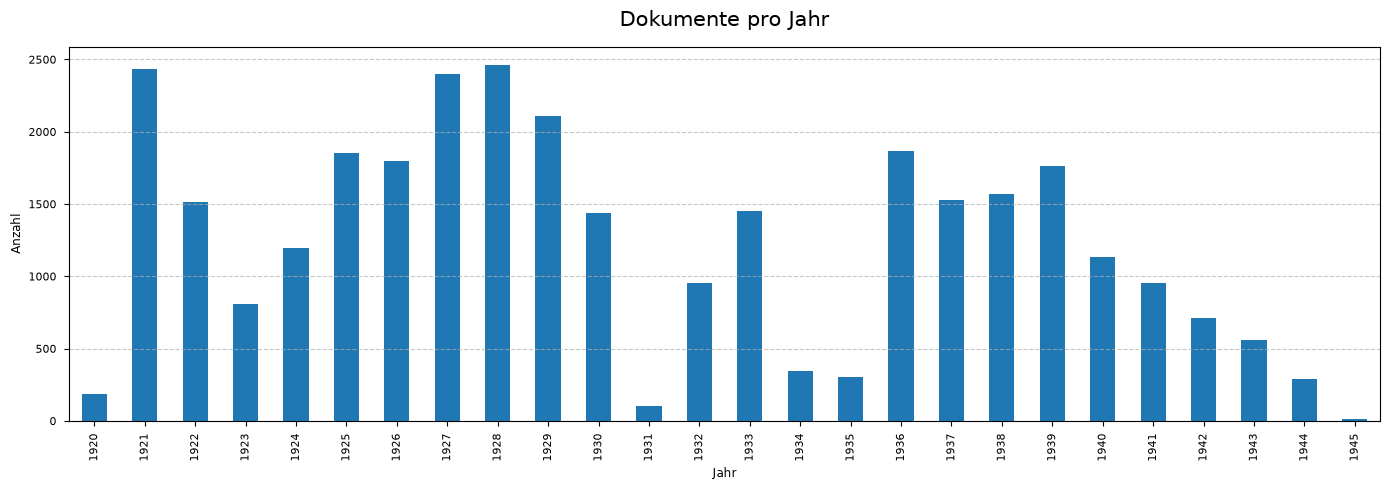

In [165]:
# data
counts_per_year = df['Jahr'].value_counts().sort_index()

# initialize Plot
fig, ax = plt.subplots(figsize=(14, 5))
counts_per_year.plot(kind='bar', ax=ax) #edgecolor='black'

# Layout/Title
ax.set_title('Dokumente pro Jahr', fontsize=15, pad=15)
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.style.use('seaborn-v0_8-paper')
save_plts(plt, "plots/metadata/documents_by_year.png")
plt.show()

## Reconstruction lost Documents

In [166]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1920                 2.0          2731.0                  2730.0              186             2544.0
 1921                22.0         23557.0                 23536.0             2435            21101.0
 1922              2491.0          6882.0                  4392.0             1515             2877.0
 1923               257.0          7986.0                  7730.0              807             6923.0
 1924              6912.0          9600.0                  2689.0             1195             1494.0
 1925              9601.0         12101.0                  2501.0             1855              646.0
 1926             11934.0         14622.0                  2689.0             1797              892.0
 1927             14536.0         18894.0                  4359.0             2402             1957.0
 1928              7049.0         21299.0                 14251.0             2464

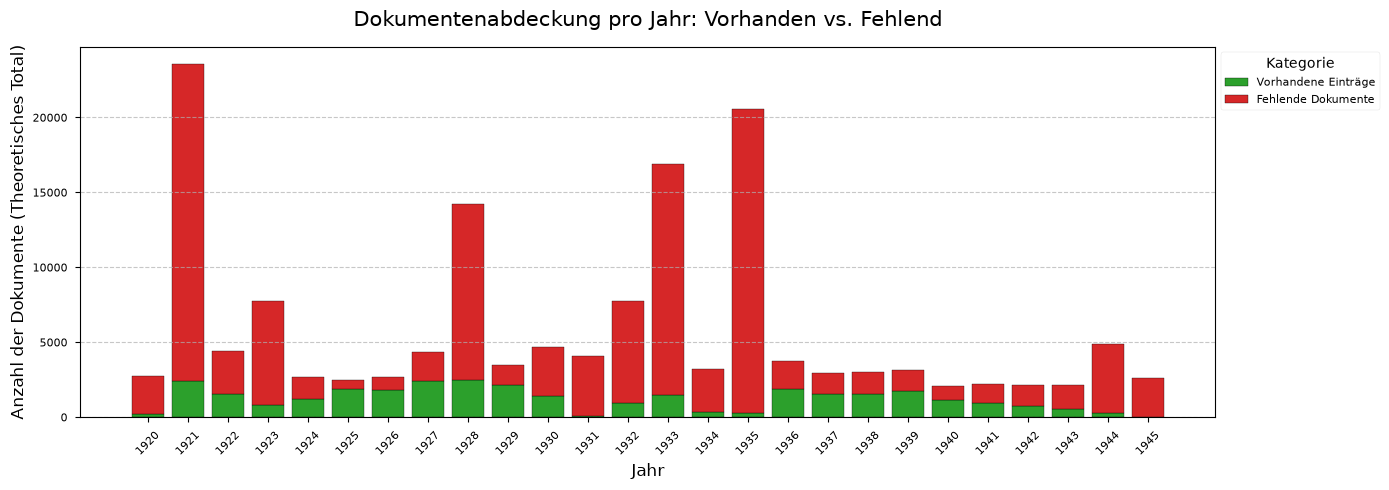

In [167]:
# data
plot_df = summary.dropna(subset=['Jahr']).copy()

# initialize Plot
fig, ax = plt.subplots(figsize=(14, 5))

# bottom bar
ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c',
    edgecolor='black'
)

# top bar
ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728',
    edgecolor='black'
)

# Layout/Title
ax.set_title('Dokumentenabdeckung pro Jahr: Vorhanden vs. Fehlend', fontsize=15, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anzahl der Dokumente (Theoretisches Total)', fontsize=12)
ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/lost_documents_by_year")
plt.show()

## Decision 

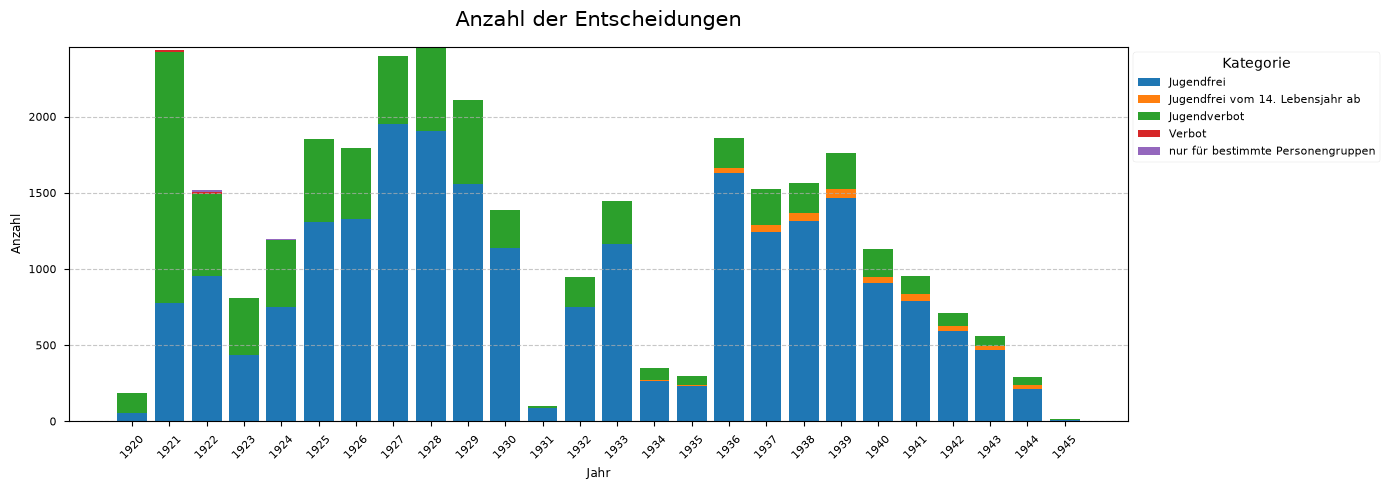

In [168]:
# data
df_decision = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

years = df_decision.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns and stack with absolute value
for decision in df_decision.columns:
    ax.bar(
        years, 
        df_decision[decision], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=decision, 
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_decision[decision]

# Layout/Title
ax.set_title('Anzahl der Entscheidungen', fontsize=15, pad=15)
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/decision_by_year.png")
plt.show()

## Silent and sound films

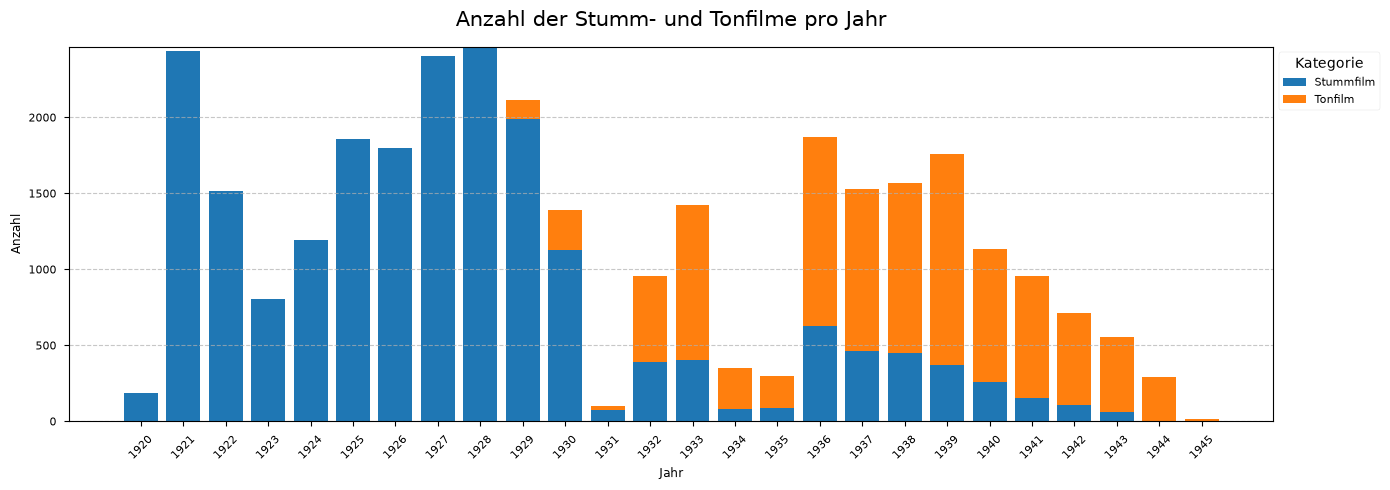

In [169]:
# data
df_silent_sound = df.groupby(['Jahr', 'Stumm-/Tonfilm']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

years = df_silent_sound.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns and stack with absolute value
for silent_sound in df_silent_sound.columns:
    ax.bar(
        years, 
        df_silent_sound[silent_sound], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=silent_sound, 
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_silent_sound[silent_sound]

# Layout/Title
ax.set_title('Anzahl der Stumm- und Tonfilme pro Jahr', fontsize=15, pad=15)
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/sound_silent_films_by_year.png")
plt.show()

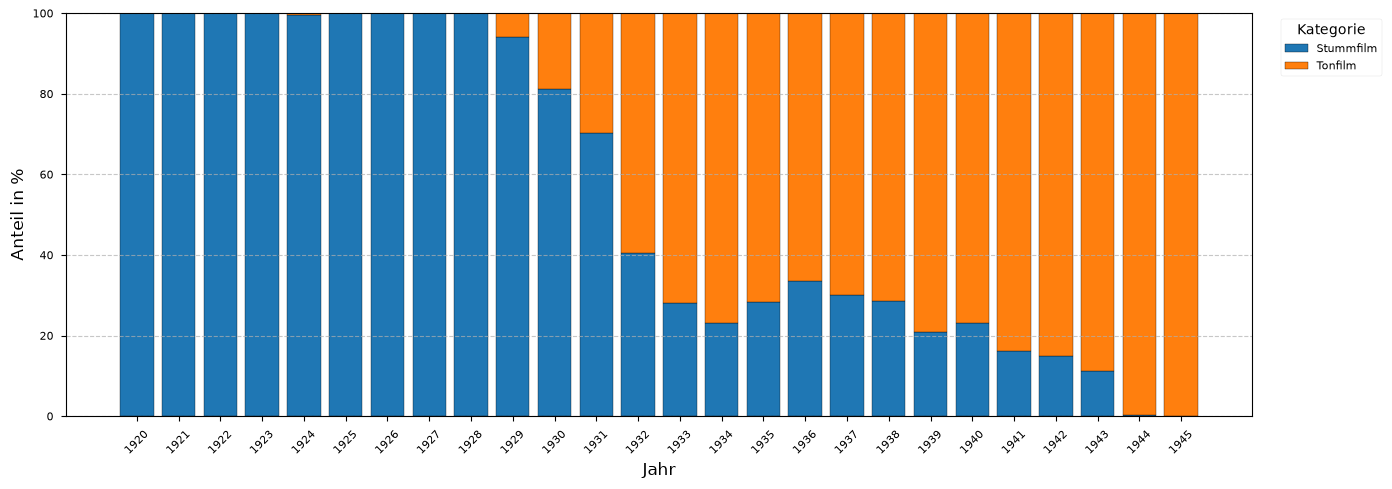

In [170]:
# data
df_grouped = df.groupby(['Jahr', 'Stumm-/Tonfilm']).size().unstack(fill_value=0)

plot_df = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
jahre = plot_df.index

# initialize Plot
fig, ax = plt.subplots(figsize=(14, 5))

bottom_values = pd.Series(0.0, index=jahre)

for type in plot_df.columns:
    ax.bar(
        jahre, 
        plot_df[type], 
        bottom=bottom_values, 
        label=type, 
        edgecolor='black'
    )
    bottom_values += plot_df[type]

# Layout/Title
# ax.set_title('Relativer Anteil der Filmarten pro Jahr (100% gestapelt)', fontsize=15, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anteil in %', fontsize=12)

ax.set_xticks(jahre)
ax.set_xticklabels(jahre, rotation=45)

ax.set_ylim(0, 100)

ax.legend(title='Kategorie', bbox_to_anchor=(1.02, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/silent_sound_relative.png")
plt.show()

## Filmtypes

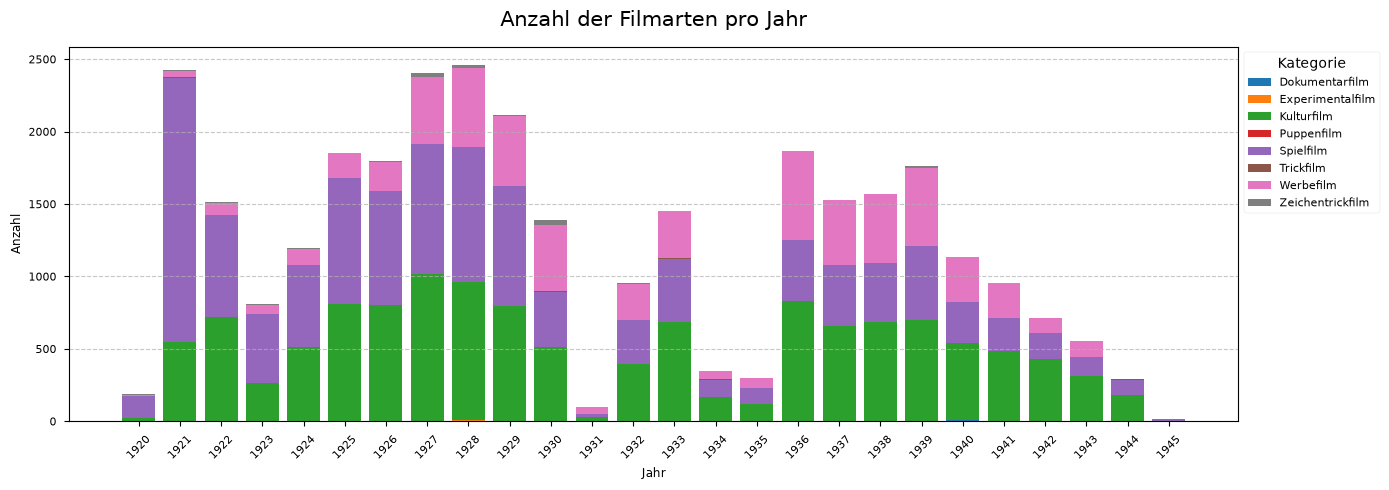

In [171]:
# data
df_filmtypes = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

# initiziale Plot
fig, ax = plt.subplots(figsize=((14, 5)))

years = df_filmtypes.index
bottom_values = pd.Series(0.0, index=years)

# iterate trough each columns (Filmtypes) and stack with absolute value
for filmtype in df_filmtypes.columns:
    ax.bar(
        years, 
        df_filmtypes[filmtype], # y_value = height of current bar
        bottom=bottom_values,   # y_starting = height  whre this segment begins
        label=filmtype, 
        edgecolor='black',
        linewidth=0.0
    )
    bottom_values += df_filmtypes[filmtype]

# Layout/Title
ax.set_title('Anzahl der Filmarten pro Jahr', fontsize=15, pad=15)
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(title='Kategorie', bbox_to_anchor=(1, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/filmtypes_by_year.png")
plt.show()

### Other

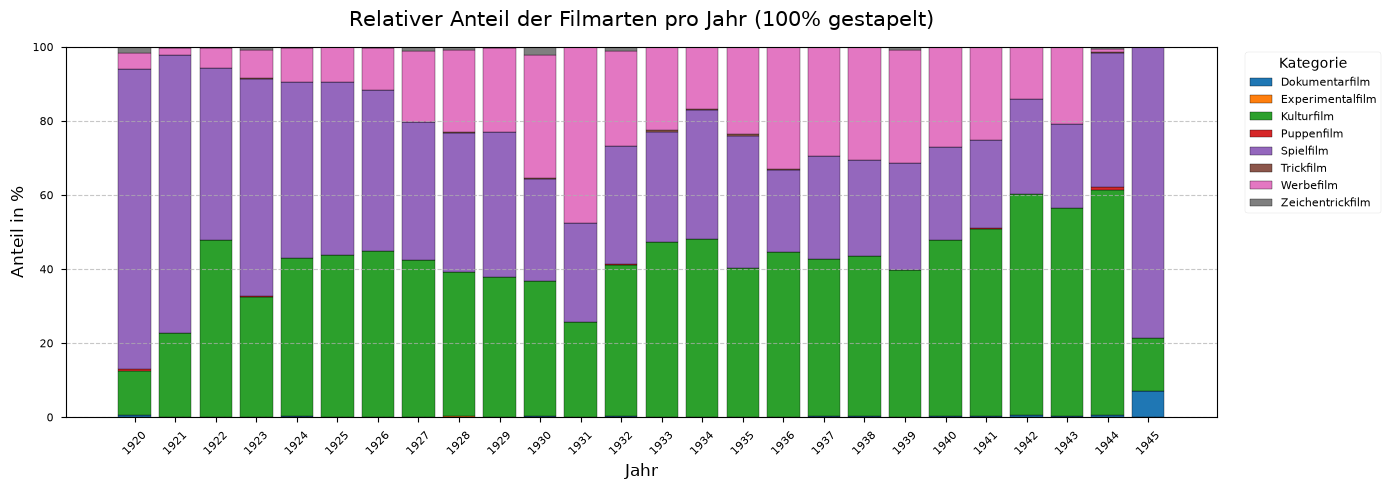

In [172]:
# data
df_grouped = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

plot_df = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
jahre = plot_df.index

# initialize Plot
fig, ax = plt.subplots(figsize=(14, 5))

bottom_values = pd.Series(0.0, index=jahre)

for filmart in plot_df.columns:
    ax.bar(
        jahre, 
        plot_df[filmart], 
        bottom=bottom_values, 
        label=filmart, 
        edgecolor='black'
    )
    bottom_values += plot_df[filmart]

# Layout/Title
ax.set_title('Relativer Anteil der Filmarten pro Jahr (100% gestapelt)', fontsize=15, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anteil in %', fontsize=12)

ax.set_xticks(jahre)
ax.set_xticklabels(jahre, rotation=45)

ax.set_ylim(0, 100)

ax.legend(title='Kategorie', bbox_to_anchor=(1.02, 1), loc='upper left')

ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
save_plts(plt, "plots/metadata/filmtypes_by_year_relative.png")
plt.show()

## Countries 

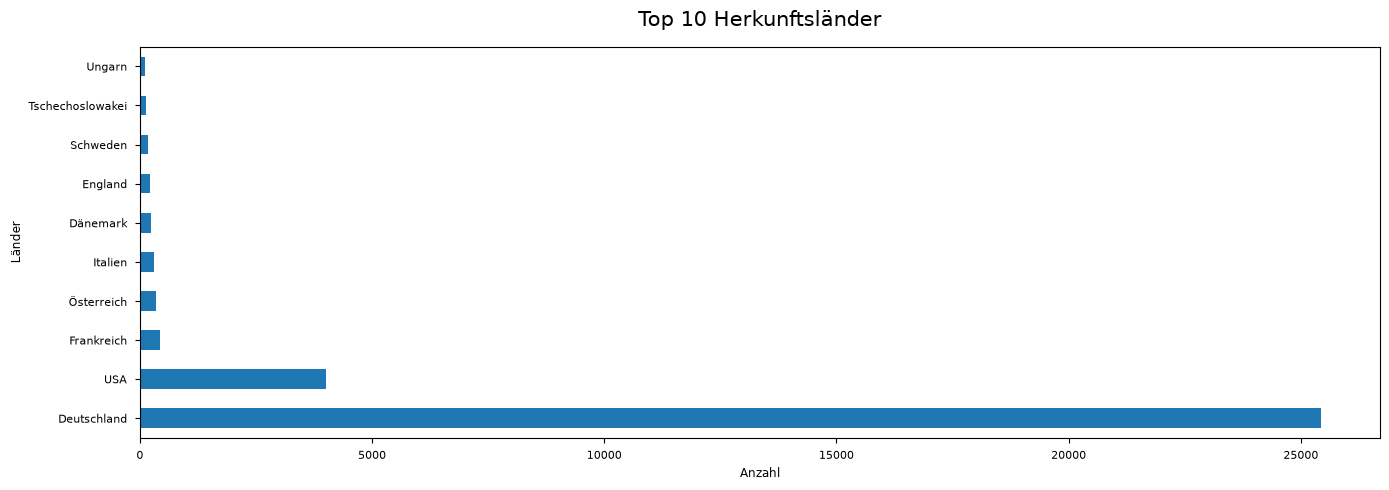

In [173]:
# data

#df_without_deutschland = df[df['Land'] != 'Deutschland']
df_countries = df.value_counts('Land')
top_countries = df_countries.head(10) 

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

top_countries.plot(kind='barh', ax=ax)

# Layout/Title
ax.set_title('Top 10 Herkunftsländer', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel('Länder')

fig.tight_layout()
plt.show()


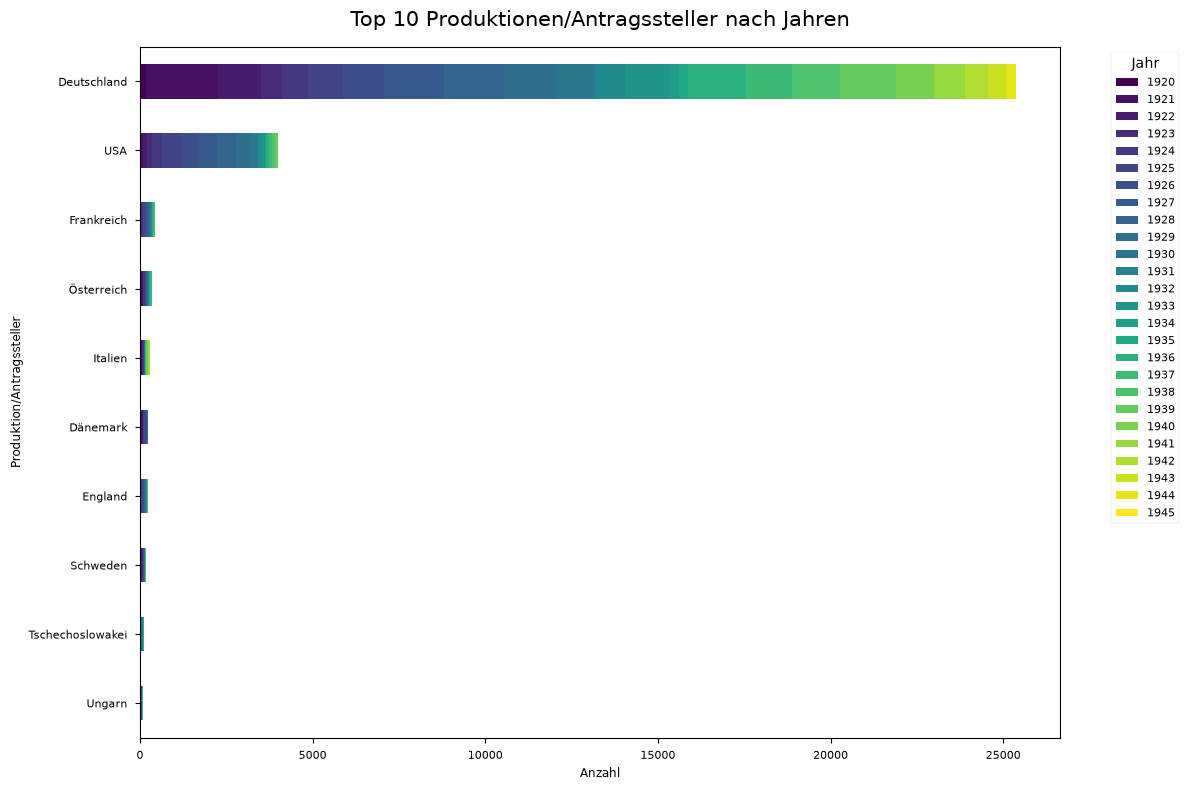

In [174]:
# 1. Identifiziere die Top 10 Produktionen (Gesamtanzahl über alle Jahre)
top_10_produktionen = df['Land'].value_counts().head(10).index

# 2. Filtere das Dataframe auf diese Top 10
df_top10 = df[df['Land'].isin(top_10_produktionen)]

# 3. Gruppieren nach Produktion und Jahr, zählen und die Jahre in Spalten unstacken
# fill_value=0 sorgt dafür, dass Jahre ohne Einträge für eine Produktion eine 0 erhalten
df_grouped = df_top10.groupby(['Land', 'Jahr']).size().unstack(fill_value=0)

# 4. Sortieren, damit die größte Gesamtproduktion oben im horizontalen Plot steht
# Matplotlib plottet barh von unten nach oben, daher kehren wir die Reihenfolge um [::-1]
df_grouped = df_grouped.loc[top_10_produktionen[::-1]]

# 5. Plot initialisieren
fig, ax = plt.subplots(figsize=(12, 8))

# 'stacked=True' erzeugt gestapelte Balken pro Jahr. 
# Wenn Sie Balken nebeneinander wollen, setzen Sie stacked=False.
df_grouped.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

# Layout/Title
ax.set_title('Top 10 Produktionen/Antragssteller nach Jahren', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel('Produktion/Antragssteller')

# Legende für die Jahre hinzufügen
ax.legend(title='Jahr', bbox_to_anchor=(1.05, 1), loc='upper left')

fig.tight_layout()
plt.show()

## Production

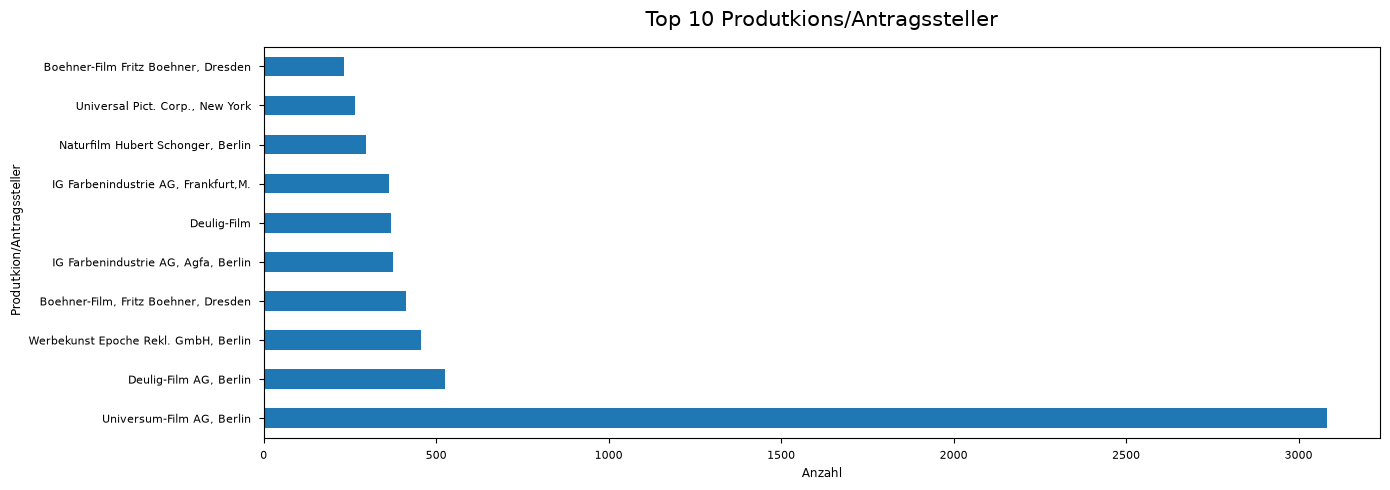

In [175]:
# data

df_producation = df.value_counts('Produktion')
top_producation = df_producation.head(10) 

# initiziale Plot
fig, ax = plt.subplots(figsize=(14, 5))

top_producation.plot(kind='barh', ax=ax)

# Layout/Title
ax.set_title('Top 10 Produtkions/Antragssteller', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel(' Produtkion/Antragssteller')

fig.tight_layout()
plt.show()



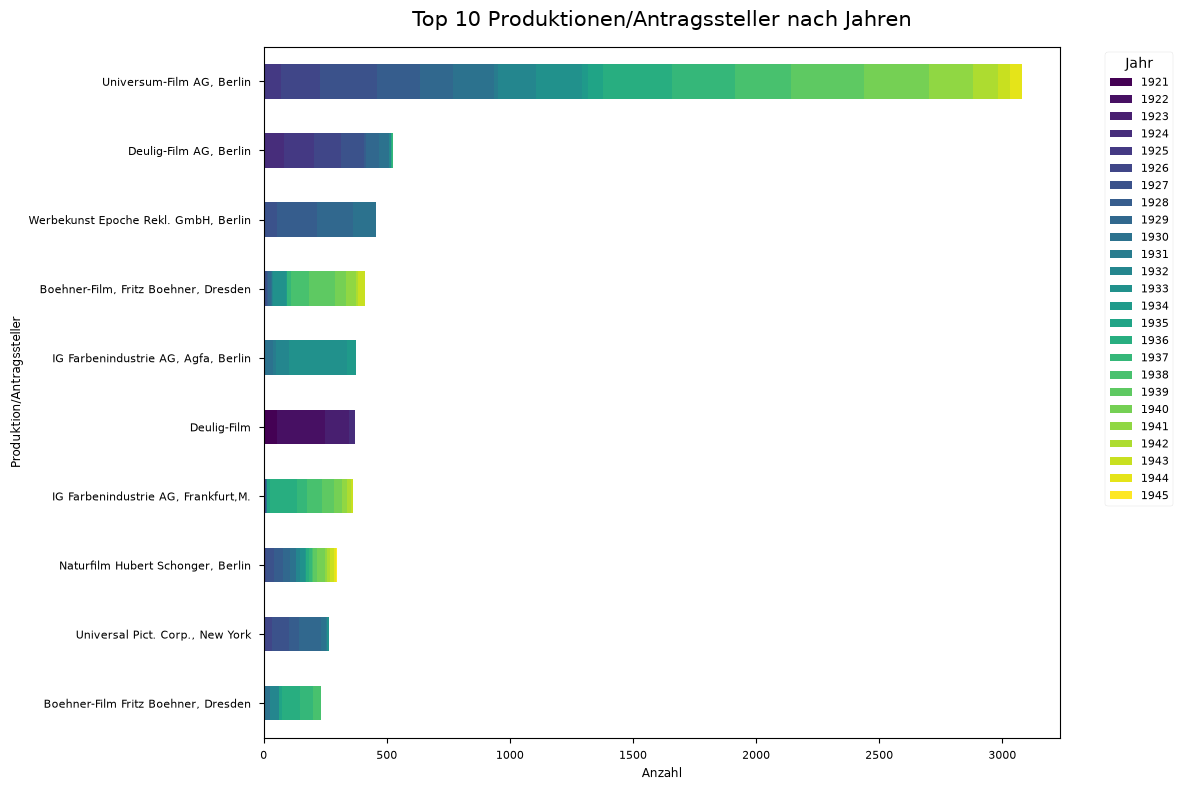

In [176]:
# 1. Identifiziere die Top 10 Produktionen (Gesamtanzahl über alle Jahre)
top_10_produktionen = df['Produktion'].value_counts().head(10).index

# 2. Filtere das Dataframe auf diese Top 10
df_top10 = df[df['Produktion'].isin(top_10_produktionen)]

# 3. Gruppieren nach Produktion und Jahr, zählen und die Jahre in Spalten unstacken
# fill_value=0 sorgt dafür, dass Jahre ohne Einträge für eine Produktion eine 0 erhalten
df_grouped = df_top10.groupby(['Produktion', 'Jahr']).size().unstack(fill_value=0)

# 4. Sortieren, damit die größte Gesamtproduktion oben im horizontalen Plot steht
# Matplotlib plottet barh von unten nach oben, daher kehren wir die Reihenfolge um [::-1]
df_grouped = df_grouped.loc[top_10_produktionen[::-1]]

# 5. Plot initialisieren
fig, ax = plt.subplots(figsize=(12, 8))

# 'stacked=True' erzeugt gestapelte Balken pro Jahr. 
# Wenn Sie Balken nebeneinander wollen, setzen Sie stacked=False.
df_grouped.plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

# Layout/Title
ax.set_title('Top 10 Produktionen/Antragssteller nach Jahren', fontsize=15, pad=15)
ax.set_xlabel('Anzahl')
ax.set_ylabel('Produktion/Antragssteller')

# Legende für die Jahre hinzufügen
ax.legend(title='Jahr', bbox_to_anchor=(1.05, 1), loc='upper left')

fig.tight_layout()
plt.show()